# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студентки гр. 2384 Лавренова Юлия и Соц Екатерина. Вариант №32

## Цель работы
Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Основные теоретические положения


**Метод наименьших квадратов (МНК)**

Пусть дана выборка $(x_i, y_i), \; i = 1, \dots, n$. Линейная регрессионная модель имеет вид:
$$
y = \beta_0 + \beta_1 x + \varepsilon,
$$
где $\varepsilon$ — случайная ошибка.

Оценки параметров $\beta_0, \beta_1$ находятся методом наименьших квадратов из условия минимизации:
$$
\sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2 \to \min.
$$

Отсюда получаем:
$$
\hat{\beta}_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \quad
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}.
$$

**Выборочные прямые регрессии**

Прямая регрессии $Y$ на $X$:
$$
\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x.
$$
Прямая регрессии $X$ на $Y$:
$$
\hat{x} = \tilde{\beta}_0 + \tilde{\beta}_1 y,
$$
где
$$
\tilde{\beta}_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (y_i - \bar{y})^2}, \quad
\tilde{\beta}_0 = \bar{x} - \tilde{\beta}_1 \bar{y}.
$$

**Коэффициент корреляции**

Выборочный коэффициент корреляции Пирсона:
$$
r_{xy} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}, \quad -1 \le r_{xy} \le 1.
$$

**Корреляционное отношение**

Корреляционное отношение (для зависимости $Y$ от $X$):
$$
\eta^2_{yx} = \frac{\sum n_j (\bar{y}_j - \bar{y})^2}{\sum (y_i - \bar{y})^2},
$$
где $\bar{y}_j$ — условные средние.

Свойство:
$$
\eta_{yx} \ge |r_{xy}|.
$$

**Нелинейные регрессионные модели**

Параболическая модель:
$$
y = \beta_0 + \beta_1 x + \beta_2 x^2.
$$

Дробно-линейная модель:
$$
y = \frac{1}{\beta_0 + \beta_1 x}.
$$

**Показатели качества регрессии**

Коэффициент детерминации:
$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}.
$$

Среднеквадратическая ошибка:
$$
S_\varepsilon = \sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}.
$$

Средняя ошибка аппроксимации:
$$
A = \frac{1}{n} \sum \left| \frac{y_i - \hat{y}_i}{y_i} \right| \cdot 100\%.
$$

## Постановка задачи
Для заданной двумерной выборки (X,Y) построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

### **1.** Отобразить двумерную выборку на графике.

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

data = pd.read_csv("sample_wine_data.csv")
data.head()

,pH,sulphates
0,3.42,0.60
1,3.53,0.72
2,3.44,0.48
3,3.09,1.06
4,3.25,0.74


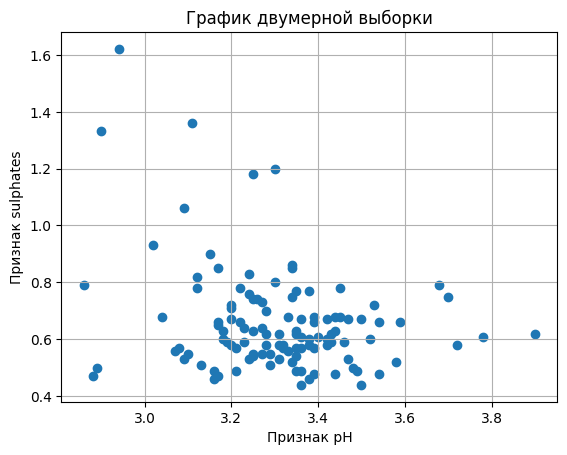

In [ ]:
import matplotlib.pyplot as plt

ph_data = data["pH"]
sulphates_data = data["sulphates"]

# построение диаграммы рассеяния
plt.scatter(ph_data, sulphates_data)
plt.xlabel('Признак pH')
plt.ylabel('Признак sulphates')
plt.title('График двумерной выборки')
plt.grid()
plt.show()

### **2.** Для заданной выборки построить уравнения средней квадратичной регрессии x на y и y на x соответственно. Построить полученные прямые на множестве выборки. Объяснить результаты.

In [ ]:
# Y на X
mean_x = np.mean(ph_data)
mean_y = np.mean(sulphates_data)

cov_xy = np.mean((ph_data - mean_x)*(sulphates_data - mean_y))
var_x = np.mean((ph_data - mean_x)**2)

a_yx = cov_xy / var_x
b_yx = mean_y - a_yx * mean_x

# X на Y
var_y = np.mean((sulphates_data - mean_y)**2)

a_xy = cov_xy / var_y
b_xy = mean_x - a_xy * mean_y

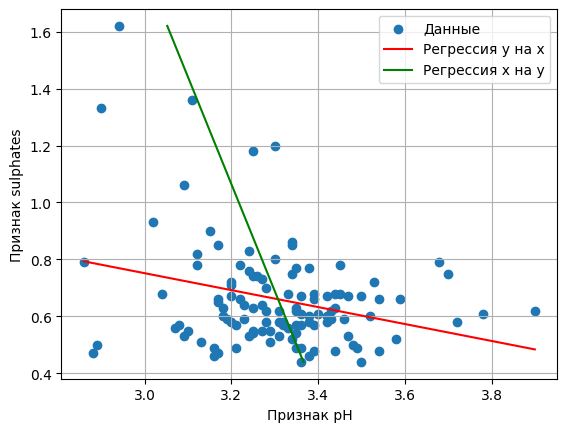

In [ ]:
plt.scatter(ph_data, sulphates_data, label='Данные')
plt.xlabel('Признак pH')
plt.ylabel('Признак sulphates')

# линия y на x
x_vals = np.linspace(min(ph_data), max(ph_data), 100)
y_vals = a_yx * x_vals + b_yx
plt.plot(x_vals, y_vals, color='red', label='Регрессия y на x')

# линия x на y
y_vals2 = np.linspace(min(sulphates_data), max(sulphates_data), 100)
x_vals2 = a_xy * y_vals2 + b_xy
plt.plot(x_vals2, y_vals2, color='green', label='Регрессия x на y')

plt.legend()
plt.grid()
plt.show()

Построенные линии регрессии между признаками $pH$ и $sulphates$ демонстрируют отрицательную зависимость: с увеличением значения $pH$ наблюдается тенденция к снижению уровня $sulphates$. Точка пересечения линий соответствует средним значениям обоих признаков, а большой угол между линиями указывает на низкий коэффициент корреляции.

Таким образом, признаки $pH$ и $sulphates$ слабо линейно связаны, данные могут содержать нелинейные зависимости, и построенные линии регрессии не способны точно описать все наблюдения.

### **3.** Составить корреляционную таблицу для нахождения выборочного корреляционного отношения. Убедиться, что неравенства $\eta_{xy} \geq |r_{xy}|$ и $\eta_{yx} \geq |r_{xy}|$ выполняются.

In [ ]:
import pandas as pd
import numpy as np

X = data['pH'].values
Y = data['sulphates'].values
n = len(X)

# Определяем количество интервалов
k = int(np.ceil(1 + 3.322 * np.log10(n)))

# Строим интервалы
bins_x = np.linspace(X.min(), X.max(), k + 1)
bins_y = np.linspace(Y.min(), Y.max(), k + 1)

# Вычисляем середины интервалов
mid_x = np.array([(bins_x[i] + bins_x[i+1]) / 2 for i in range(k)])
mid_y = np.array([(bins_y[j] + bins_y[j+1]) / 2 for j in range(k)])

# Строим двумерную гистограмму
H, xedges, yedges = np.histogram2d(X, Y, bins=[bins_x, bins_y])
H = H.astype(int)

# Создаем подписи для строк и столбцов (используем середины интервалов)
row_labels = [f'{mid_x[i]:.3f}' for i in range(k)]
col_labels = [f'{mid_y[j]:.3f}' for j in range(k)]

# Суммы по строкам и столбцам
row_sums = H.sum(axis=1)   # n_i
col_sums = H.sum(axis=0)   # n_j

# Взвешенные суммы
weighted_sum_y = H @ mid_y  # для каждой строки: сумма n_ij * y_j
weighted_sum_x = H.T @ mid_x  # для каждого столбца: сумма n_ij * x_i

df_corr = pd.DataFrame(H, index=row_labels, columns=col_labels).astype(object)

# Заменяем нули на "—"
for i in range(k):
    for j in range(k):
        if H[i, j] == 0:
            df_corr.iloc[i, j] = '—'
# E[Y | X]
y_mean_given_x = []
for i in range(k):
    if row_sums[i] != 0:
        val = np.sum(H[i, :] * mid_y) / row_sums[i]
    else:
        val = 0
    y_mean_given_x.append(val)

# E[X | Y]
x_mean_given_y = []
for j in range(k):
    if col_sums[j] != 0:
        val = np.sum(H[:, j] * mid_x) / col_sums[j]
    else:
        val = 0
    x_mean_given_y.append(val)

df_corr = pd.DataFrame(H, index=row_labels, columns=col_labels).astype(object)

# Заменяем нули
for i in range(k):
    for j in range(k):
        if H[i, j] == 0:
            df_corr.iloc[i, j] = '—'

# Добавляем n_i и условные средние E[Y|X]
df_corr[r'$n_{x_i}$'] = [f'{row_sums[i]:.0f}' for i in range(k)]
df_corr[r'$\overline{y}_{x_i}$'] = [f'{y_mean_given_x[i]:.3f}' for i in range(k)]

# Добавляем нижнюю строку n_j
bottom_row = [f'{col_sums[j]:.0f}' for j in range(k)] + [f'{n:.0f}', '']
df_corr.loc[r'$n_{y_j}$'] = bottom_row

# Добавляем строку условных средних E[X|Y]
bottom_mean_row = [f'{x_mean_given_y[j]:.3f}' for j in range(k)] + ['', '']
df_corr.loc[r'$\overline{x}_{y_j}$'] = bottom_mean_row

df_corr.index.name = 'pH \\ sulphates'
display(Markdown(df_corr.to_markdown()))

| pH \ sulphates       | 0.514   | 0.661   | 0.809   | 0.956   | 1.104   | 1.251   | 1.399   | 1.546   | $n_{x_i}$   | $\overline{y}_{x_i}$   |
|:---------------------|:--------|:--------|:--------|:--------|:--------|:--------|:--------|:--------|:------------|:-----------------------|
| 2.925                | 2       | —       | 1       | —       | —       | —       | 1       | 1       | 5           | 0.956                  |
| 3.055                | 4       | 1       | —       | 1       | 1       | —       | 1       | —       | 8           | 0.772                  |
| 3.185                | 8       | 11      | 6       | 1       | —       | —       | —       | —       | 26          | 0.661                  |
| 3.315                | 18      | 11      | 7       | —       | —       | 2       | —       | —       | 38          | 0.650                  |
| 3.445                | 10      | 14      | 2       | —       | —       | —       | —       | —       | 26          | 0.616                  |
| 3.575                | 2       | 4       | —       | —       | —       | —       | —       | —       | 6           | 0.612                  |
| 3.705                | 1       | —       | 2       | —       | —       | —       | —       | —       | 3           | 0.710                  |
| 3.835                | —       | 2       | —       | —       | —       | —       | —       | —       | 2           | 0.661                  |
| $n_{y_j}$            | 45      | 43      | 18      | 2       | 1       | 2       | 2       | 1       | 114         |                        |
| $\overline{x}_{y_j}$ | 3.301   | 3.366   | 3.308   | 3.120   | 3.055   | 3.315   | 2.990   | 2.925   |             |                        |

In [ ]:
# Общие средние
x_mean = np.mean(X)
y_mean = np.mean(Y)

# Дисперсии
var_x = np.var(X, ddof=0)
var_y = np.var(Y, ddof=0)

# η_yx (Y от X)
eta_yx = np.sqrt(
    np.sum(row_sums * (np.array(y_mean_given_x) - y_mean)**2) / (n * var_y)
)

# η_xy (X от Y)
eta_xy = np.sqrt(
    np.sum(col_sums * (np.array(x_mean_given_y) - x_mean)**2) / (n * var_x)
)

# Коэффициент корреляции Пирсона
r_xy = np.corrcoef(X, Y)[0, 1]

# Вывод результатов
print(f"η_xy = {eta_xy:.3f}")
print(f"η_yx = {eta_yx:.3f}")
print(f"|r_xy|   = {abs(r_xy):.3f}")

η_xy = 0.421
η_yx = 0.392
|r_xy|   = 0.281


В ходе анализа двумерной выборки признаков $pH$ и $sulphates$ рассчитаны корреляционные отношения и коэффициент линейной корреляции:

$\eta_{xy}=0.421$ - корреляционное отношение X от Y

$\eta_{yx}=0.392$ — корреляционное отношение Y от X

$∣r_{xy}∣ = 0.281$ — коэффициент корреляции

Проверка неравенств показала, что

$$\eta_{xy} \geq |r_{xy}|$$
и
$$\eta_{yx} \geq |r_{xy}|,$$ что подтверждает теоретическое свойство корреляционного отношения: оно всегда больше или равно по модулю линейному коэффициенту корреляции.

Значение корреляционного отношения $|r_{xy}| = 0.281$ свидетельствует о слабой линейной зависимости составляющей в связи между признаками $pH$ и $sulphates$.

### **4.** Для заданной выборки построить корреляционную кривую параболического вида $y=\beta_0 +\beta_1x+\beta_2x^2$, сделать выводы.

Параметры модели: β0 = 9.111, β1 = -4.801, β2 = 0.677


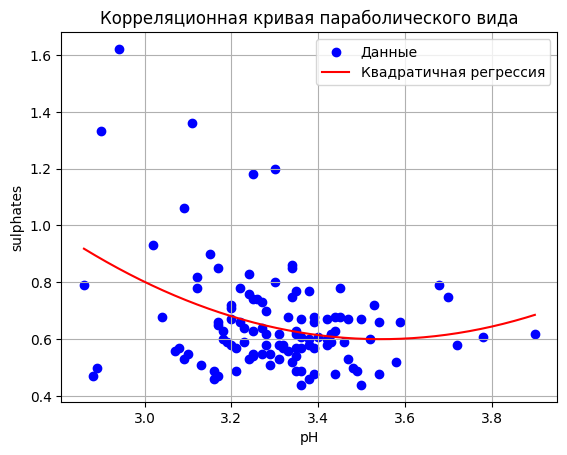

In [ ]:
from numpy.linalg import lstsq

X_mat = np.column_stack((np.ones(n), X, X**2))

# Решаем МНК: beta = (X^T X)^(-1) X^T Y
beta, residuals, rank, s = lstsq(X_mat, Y, rcond=None)

beta0, beta1, beta2 = beta
print(f"Параметры модели: β0 = {beta0:.3f}, β1 = {beta1:.3f}, β2 = {beta2:.3f}")

# Построим график
x_vals = np.linspace(X.min(), X.max(), 200)
y_vals = beta0 + beta1*x_vals + beta2*x_vals**2

plt.scatter(X, Y, color='blue', label='Данные')
plt.plot(x_vals, y_vals, color='red', label='Квадратичная регрессия')
plt.xlabel('pH')
plt.ylabel('sulphates')
plt.title('Корреляционная кривая параболического вида')
plt.legend()
plt.grid()
plt.show()

Параболическая регрессия показывает, что зависимость $sulphates$ от $pH$ является нелинейной. С увеличением $pH$ сначала наблюдается снижение содержания $sulphates$, после чего при больших значениях $pH$ кривая слегка возрастает. Модель отражает общую тенденцию, но данные сильно разбросаны вокруг кривой.

### **5.** Для заданной выборки построить корреляционную кривую в зависимости от номера варианта и сделать вывод:

In [ ]:
def plot_corr_curvature(model_func, name):
  x_vals = np.linspace(X.min(), X.max(), 200)
  y_vals = model_func(x_vals)

  figure, ax = plt.subplots()
  ax.scatter(X, Y, color='blue', label='Данные')
  ax.plot(x_vals, y_vals, color='red', label='Модель')
  ax.set_xlabel('pH')
  ax.set_ylabel('sulphates')
  ax.set_title(f'Корреляционная кривая: {name}')
  ax.legend()
  ax.grid()


#### c. дробно-линейная функция: $y=\frac{1}{\beta_0+\beta_1x}$


Дробно-линейная функция: y = 1/(0.438 + 0.352*x)


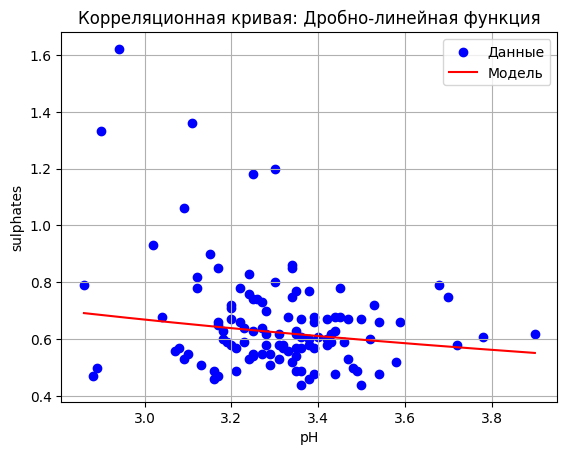

In [ ]:
A = np.column_stack((np.ones(n), X))
b = 1 / Y
beta = lstsq(A, b, rcond=None)[0]
beta0, beta1 = beta
print(f"Дробно-линейная функция: y = 1/({beta0:.3f} + {beta1:.3f}*x)")
plot_corr_curvature(lambda x: 1 / (beta0 + beta1 * x), "Дробно-линейная функция")

По результатам подбора дробно-линейной функции вида $$y = \dfrac{1}{\beta_0 + \beta_1 x}$$
получена модель:
$$y = \frac{1}{0.438 + 0.352 \cdot x}$$

Построенная корреляционная кривая имеет убывающий характер: с ростом значения $pH$ предсказанное значение $sulphates$ монотонно снижается, что согласуется с отрицательной зависимостью, выявленной ранее при анализе линейной регрессии. На графике видно, что разброс точек относительно кривой значителен — модель улавливает общую тенденцию, однако не описывает индивидуальные наблюдения точно. Дробно-линейная форма не даёт существенного преимущества перед простой линейной регрессией и немного хуже аппроксимирует, чем параболическая кривая. Это подтверждает ранее сделанный вывод о слабой связи между признаками $pH$ и $sulphates$.

### **6.** Вычислить следующие показатели качества регрессии для каждой кривой и сделать выводы:

*   теоретический коэффициент детерминации $R^2$
*   средняя квадратическая ошибка $S_{\varepsilon}$
*   средняя ошибка аппроксимации (приближения) $A$


In [ ]:
X = data['pH'].values
y = 1/(beta0 + (beta1 * X))

# коэффициент детерминации
SS_res = np.sum((Y - y) ** 2)
SS_tot = np.sum((Y - np.mean(Y)) ** 2)
R2 = 1 - (SS_res / SS_tot)

# cредняя квадратическая ошибка
S_epsilon = np.sqrt(np.mean((Y - y) ** 2))

# средняя ошибка аппроксимации A
A =  np.mean(np.abs(Y - y) / Y) * 100  # в процентах

# Выводим результаты
print(f"Теоретический коэффициент детерминации R²: {R2:.4f}")
print(f"Средняя квадратическая ошибка Sε: {S_epsilon:.4f}")
print(f"Средняя ошибка аппроксимации A: {A:.4f}")

Теоретический коэффициент детерминации R²: 0.0246
Средняя квадратическая ошибка Sε: 0.1849
Средняя ошибка аппроксимации A: 16.2970


Получены следующие метрики оценки качества дробно-линейной модели​:

$R^2 = 0.0246$  — модель объясняет лишь $2.5\%$ дисперсии признака $sulphates$, что свидетельствует о крайне низкой объясняющей способности модели.

$S_\varepsilon = 0.1849$ — среднее отклонение предсказанных значений от фактических составляет $0.185$, что является значительным на фоне среднего $sulphates \approx 0.65$.

$A = 16.30\%$ — средняя ошибка аппроксимации превышает $16\%$, что по стандартным критериям оценки соответствует неудовлетворительному качеству.

Таким образом, дробно-линейная функция не является хорошей моделью для описания зависимости между признаками  $pH$ и $sulphates$. Низкие значения метрик обусловлены слабой корреляцией между признаками и значительным случайным разбросом данных.

## **Выводы**
В ходе выполнения практической работы проведён регрессионный анализ двумерной выборки признаков $pH$ и $sulphates$ и найдены корреляционные отношения.

Построенная линейная регрессия и рассчитанные корреляционные характеристики показали наличие слабой отрицательной линейной зависимости между признаками: коэффициент линейной корреляции $|r_{xy}| = 0.281$ свидетельствует о том, что с ростом $pH$ наблюдается незначительная тенденция к снижению $sulphates$.

Для описания нелинейной зависимости были построены две корреляционные кривые:

- параболическая модель $y = 9.111 - 4.801x + 0.677x^2$ - уловила характер зависимости, однако также не обеспечила высокого качества аппроксимации.
- дробно-линейная модель $y = \dfrac{1}{0.438 + 0.352x}$ - показала крайне низкое качество аппроксимации: $R^2 = 0.025$, $S_\varepsilon = 0.185$, $A = 16.30\%$

Обе модели подтверждают общий вывод: зависимость между $pH$ и $sulphates$ слабая, и ни линейная, ни рассмотренные нелинейные модели не способны точно описать данную выборку.